In [3]:
import pandas as pd 
import numpy as np

from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler

from keras.models import Sequential
from keras.layers import Dense
from scikeras.wrappers import KerasRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

import ipympl 
%matplotlib ipympl


file_path = '../../Dataset/eplusout.csv'

df = pd.read_csv(file_path)

# df.set_index('Date Time', inplace=True)

display(df)

,Date/Time,Environment:Site Outdoor Air Drybulb Temperature [C](TimeStep),AUD03:Zone Mean Air Temperature [C](TimeStep),AUD04:Zone Mean Air Temperature [C](TimeStep),AUD05:Zone Mean Air Temperature [C](TimeStep),AUD06:Zone Mean Air Temperature [C](TimeStep),AUD18:Zone Mean Air Temperature [C](TimeStep),AUD17:Zone Mean Air Temperature [C](TimeStep),AUD16:Zone Mean Air Temperature [C](TimeStep),AUD15:Zone Mean Air Temperature [C](TimeStep),...,PROJB HTG SETPT SCH:Schedule Value [](TimeStep),PROJB CLG SETPT SCH:Schedule Value [](TimeStep),PROJD HTG SETPT SCH:Schedule Value [](TimeStep),PROJD CLG SETPT SCH:Schedule Value [](TimeStep),PROJC HTG SETPT SCH:Schedule Value [](TimeStep),PROJC CLG SETPT SCH:Schedule Value [](TimeStep),OFFICE HTG SETPT SCH:Schedule Value [](TimeStep),OFFICE CLG SETPT SCH:Schedule Value [](TimeStep),EMPLOYEE HTG SETPT SCH:Schedule Value [](TimeStep),EMPLOYEE CLG SETPT SCH:Schedule Value [](TimeStep)
0,01/01 00:05:00,6.7,20.243276,20.253769,20.486017,20.489327,20.243276,20.253770,20.253692,20.035031,...,20.0,23.8889,20.0,23.8889,20.0,23.8889,20.0,23.8889,20.0,23.8889
1,01/01 00:10:00,6.7,20.424724,20.243246,20.009726,20.033894,20.424888,20.243248,20.243332,20.448564,...,20.0,23.8889,20.0,23.8889,20.0,23.8889,20.0,23.8889,20.0,23.8889
2,01/01 00:15:00,6.7,20.003879,20.253802,20.485985,20.446776,20.003880,20.253804,20.253719,20.006871,...,20.0,23.8889,20.0,23.8889,20.0,23.8889,20.0,23.8889,20.0,23.8889
3,01/01 00:20:00,6.7,20.520028,20.243231,20.009741,20.006957,20.520017,20.243233,20.243317,20.489210,...,20.0,23.8889,20.0,23.8889,20.0,23.8889,20.0,23.8889,20.0,23.8889
4,01/01 00:25:00,6.7,20.153758,20.253829,20.485961,20.489271,20.153856,20.253833,20.253742,20.033655,...,20.0,23.8889,20.0,23.8889,20.0,23.8889,20.0,23.8889,20.0,23.8889
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105115,12/31 23:40:00,3.3,20.243799,20.484873,20.485052,20.007372,20.028497,20.484876,20.485085,20.007372,...,20.0,23.8889,20.0,23.8889,20.0,23.8889,20.0,23.8889,20.0,23.8889
105116,12/31 23:45:00,3.3,20.244366,20.010737,20.010505,20.488761,20.470631,20.010738,20.010478,20.488762,...,20.0,23.8889,20.0,23.8889,20.0,23.8889,20.0,23.8889,20.0,23.8889
105117,12/31 23:50:00,3.3,20.238186,20.484855,20.485032,20.007384,20.024529,20.484857,20.485065,20.007384,...,20.0,23.8889,20.0,23.8889,20.0,23.8889,20.0,23.8889,20.0,23.8889
105118,12/31 23:55:00,3.3,20.244323,20.010750,20.010513,20.488750,20.468784,20.010753,20.010486,20.488751,...,20.0,23.8889,20.0,23.8889,20.0,23.8889,20.0,23.8889,20.0,23.8889


In [18]:
df_2 = pd.DataFrame()

# df_2["Date_Time"]                                                                =   df["Date/Time"]

df_2["Facility_Demand_Rate_kW"]                                                     = df["Whole Building:Facility Total Electricity Demand Rate [W](TimeStep)"] / 1000

df_2["Environment:Site Outdoor Air Drybulb Temperature [C](TimeStep)"]           =   df["Environment:Site Outdoor Air Drybulb Temperature [C](TimeStep)"] 

room_names = ["AUD01", "AUD02", "AUD03", "AUD04", "AUD05", "AUD06", "AUD07", "AUD08", "AUD09", "AUD10", "AUD11", "AUD12", "AUD13", "AUD14", "AUD15", "AUD16", "AUD17", "AUD18", "AUD19", "AUD20",
              "CONCPROM1", "CONCPROM2", "TLTPROM1", "TLTPROM2", "COFFEEBAR", "GAMEROOM", "LOBBY", "TICKETS", "PROJA", "PROJB", "PROJC", "PROJD", "OFFICE"]  # Add more room names as needed

# Initialize a list to hold DataFrames for each room
room_dfs = []

# Iterate over room names
for room_name in room_names:
    # Construct column names
    zone_mean_air_temp_col = f"{room_name}:Zone Mean Air Temperature [C](TimeStep)"
    htg_setpt_col = f"{room_name} HTG SETPT SCH:Schedule Value [](TimeStep)"
    clg_setpt_col = f"{room_name} CLG SETPT SCH:Schedule Value [](TimeStep)"

    # Extract columns from the original DataFrame and append to the list
    room_df = df[[zone_mean_air_temp_col, htg_setpt_col, clg_setpt_col]]
    room_df.columns = [f"{room_name}_Zone_Mean_Air_Temperature", f"{room_name}_HTG_SETPT", f"{room_name}_CLG_SETPT"]
    room_dfs.append(room_df)

# Concatenate all DataFrames along the columns axis
df_2 = pd.concat([df_2] + room_dfs, axis=1)

# Adding Employee column creates an error so we add it manually
df_2["EMPLOYEE_Zone_Mean_Air_Temperature"]                            =   df["EMPLOYEE:Zone Mean Air Temperature [C](TimeStep)"]
df_2["EMPLOYEE_HTG_SETPT"]                                            =   df["EMPLOYEE HTG SETPT SCH:Schedule Value [](TimeStep)"]

# df_2["EMPLOYEE_CLG_SETPT"]                                            =   df["EMPLOYEE CLG SETPT SCH:Schedule Value [](TimeStep)"]
df_2["EMPLOYEE_CLG_SETPT"]                                            =   df.iloc[:, -1]




display(df_2)

,Facility_Demand_Rate_kW,Environment:Site Outdoor Air Drybulb Temperature [C](TimeStep),AUD01_Zone_Mean_Air_Temperature,AUD01_HTG_SETPT,AUD01_CLG_SETPT,AUD02_Zone_Mean_Air_Temperature,AUD02_HTG_SETPT,AUD02_CLG_SETPT,AUD03_Zone_Mean_Air_Temperature,AUD03_HTG_SETPT,...,PROJC_CLG_SETPT,PROJD_Zone_Mean_Air_Temperature,PROJD_HTG_SETPT,PROJD_CLG_SETPT,OFFICE_Zone_Mean_Air_Temperature,OFFICE_HTG_SETPT,OFFICE_CLG_SETPT,EMPLOYEE_Zone_Mean_Air_Temperature,EMPLOYEE_HTG_SETPT,EMPLOYEE_CLG_SETPT
0,190.426026,6.7,20.475174,20.0,23.8889,20.480841,20.0,23.8889,20.243276,20.0,...,23.8889,20.001310,20.0,23.8889,20.338029,20.0,23.8889,20.001048,20.0,23.8889
1,190.360637,6.7,20.033642,20.0,23.8889,20.047459,20.0,23.8889,20.424724,20.0,...,23.8889,19.999363,20.0,23.8889,20.306129,20.0,23.8889,20.000008,20.0,23.8889
2,190.331229,6.7,20.489567,20.0,23.8889,20.478936,20.0,23.8889,20.003879,20.0,...,23.8889,20.489683,20.0,23.8889,20.275221,20.0,23.8889,20.479038,20.0,23.8889
3,190.456673,6.7,20.056314,20.0,23.8889,20.043813,20.0,23.8889,20.520028,20.0,...,23.8889,20.093437,20.0,23.8889,20.244951,20.0,23.8889,20.057682,20.0,23.8889
4,190.297697,6.7,20.473177,20.0,23.8889,20.477356,20.0,23.8889,20.153758,20.0,...,23.8889,20.001184,20.0,23.8889,20.215148,20.0,23.8889,20.488301,20.0,23.8889
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105115,190.877238,3.3,20.252889,20.0,23.8889,20.489481,20.0,23.8889,20.243799,20.0,...,23.8889,20.272905,20.0,23.8889,20.243910,20.0,23.8889,20.404130,20.0,23.8889
105116,191.321030,3.3,20.244394,20.0,23.8889,20.006850,20.0,23.8889,20.244366,20.0,...,23.8889,20.244057,20.0,23.8889,20.508249,20.0,23.8889,20.006278,20.0,23.8889
105117,190.905346,3.3,20.252896,20.0,23.8889,20.489467,20.0,23.8889,20.238186,20.0,...,23.8889,20.271679,20.0,23.8889,20.064467,20.0,23.8889,20.401844,20.0,23.8889
105118,191.417577,3.3,20.244388,20.0,23.8889,20.006865,20.0,23.8889,20.244323,20.0,...,23.8889,20.244046,20.0,23.8889,20.000504,20.0,23.8889,20.006295,20.0,23.8889


In [20]:
X = df_2.drop('Facility_Demand_Rate_kW', axis = 1)
y = df_2.Facility_Demand_Rate_kW

#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

# Split data into training and temporary data (80% training, 20% temporary)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)

# Split temporary data into testing and validation sets (50% testing, 50% validation)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)


#Standardize features by removing the mean and scaling to unit variance
scaler=StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               13312     
                                                                 
 dense_1 (Dense)             (None, 128)               16512     
                                                                 
 dense_2 (Dense)             (None, 128)               16512     
                                                                 
 dense_3 (Dense)             (None, 128)               16512     
                                                                 
 dense_4 (Dense)             (None, 1)                 129       
                                                                 
Total params: 62977 (246.00 KB)
Trainable params: 62977 (246.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/250


26

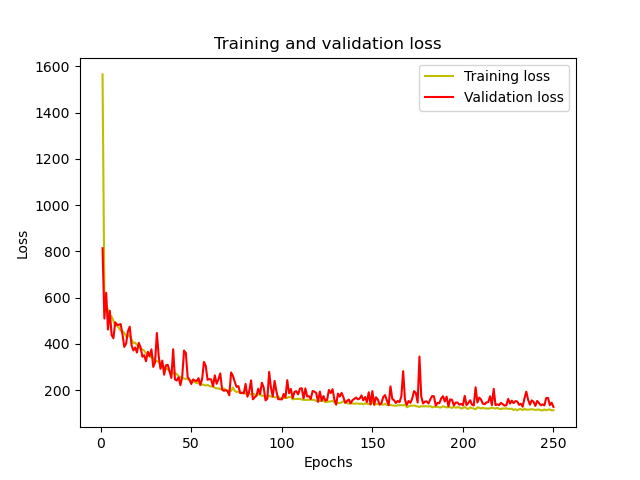

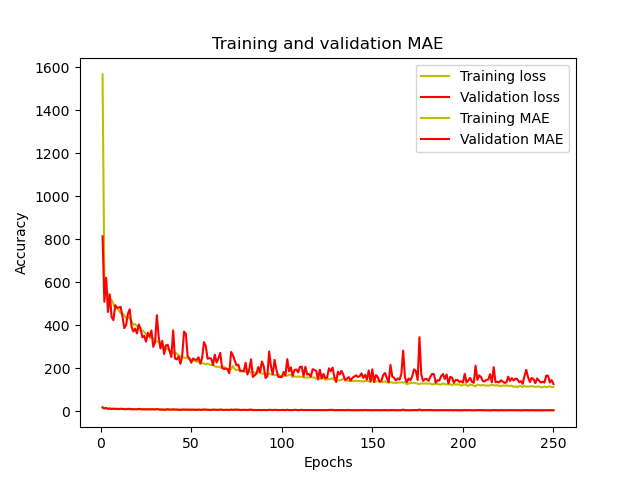

329/329 [==============================] - 1s 2ms/step
Training R^2: 0.9926761613990086
Validation R^2: 0.9902470201521318


In [21]:
epoch_values = 250

# define the model
# Experiment with deeper and wider networks

# Sequential constructor automatically/implicitly creates an input layer when the first layer is added to the model. Its shape is determined by the "input_dim" parameter of the first layer
model = Sequential()

# Dense layers (all connected) are added to the neural network with the specified neuron amount
# 128 neurons in the 1st hidden layer 
model.add(Dense(128, input_dim=103, activation='relu'))

# 64 neurons in the 2nd hidden layer
model.add(Dense(128, activation='tanh'))

# 64 neurons in the 2nd hidden layer
model.add(Dense(128, activation='relu'))

    # 64 neurons in the 2nd hidden layer
model.add(Dense(128, activation='relu'))

# Output layer, linear activation function does nothing except adding the results of previous neurons together
model.add(Dense(1, activation='linear'))

model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])
model.summary()

history = model.fit(X_train_scaled, y_train, validation_data=[X_val_scaled, y_val] , epochs = epoch_values)
#validation_data=[X_test, y_test]

#plot the training and validation accuracy and loss at each epoch
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


acc = history.history['mae']
val_acc = history.history['val_mae']
plt.plot(epochs, acc, 'y', label='Training MAE')
plt.plot(epochs, val_acc, 'r', label='Validation MAE')
plt.title('Training and validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


# 1. Obtain predictions for both training and testing sets
train_predictions = model.predict(X_train_scaled)
val_predictions = model.predict(X_val_scaled)

# 2. Calculate R^2 scores
train_r2 = r2_score(y_train, train_predictions)
val_r2 = r2_score(y_val, val_predictions)

print("Training R^2:", train_r2)
print("Validation R^2:", val_r2)

39 min 29 secs

In [22]:
# Save the model
model.save('ANN_Model.keras')

In [24]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

test_predictions = model.predict(X_test_scaled)

test_r2 = r2_score(y_test, test_predictions)

testMaeScore = mean_absolute_error(y_test, test_predictions)
print("MAE of the test set:", testMaeScore)

testMseScore = (mean_squared_error(y_test, test_predictions))
print("MSE of the test set:", testMseScore)

print("Test R^2:", test_r2)

329/329 [==============================] - 1s 3ms/step
MAE of the test set: 5.614190276960699
MSE of the test set: 136.9332458577287
Test R^2: 0.9893947254344656


: 